In [ ]:
from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))

### ¿Geopandas?

Geopandas enables the use and manipulation of geospatial data in Python. It extends the common datatype used in pandas to allow for the many and unique geometric operations: GeoSeries and GeoDataFrame. Geopandas is also built on top of shapely for its geometric operation; its underlying datatype allows Geopandas to run blazingly fast and is appropriate for many machine learning pipelines that require large geospatial datasets.

### Instalation 

Following steps:

#### 1. create new environment

conda creare -name new_env

#### 2. Activate new environment
conda activate new_env

#### 3. Install package 

conda install -c conda-forge python=3 geopandas

### Geopandas data types

Shapefile (.shp): vector data that stores geospatial information such as topology, shape geometry, coordinate etc

GeoJSON (.geojson): geospatial information and relevant characteristics (object or string)

Finally, Geopandas creates an additional geometry column


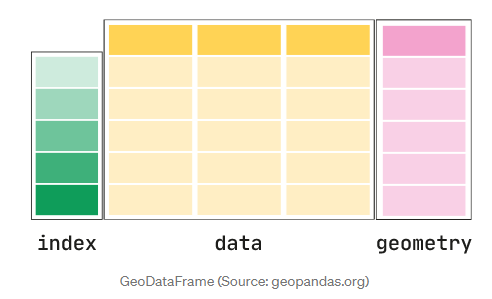


### Coordinate Reference Systems (crs)

The coordinate reference systems tell us how GeodataFrame o GeoSeries relate to places on Earth

#### relevant operations: setting a projection and re-projecting 

setting projection: geopandas.read_file() most of time includes projection information. Check using "Geoseries.crs"
If GeoDataframe does not include projection, hence use data["geometry"].set_crs(epsg=4326) for WGS-84.

### WGS-84: 
The Global Positioning System uses the World Geodetic System (WGS84) as its reference coordinate system. It's made up of a reference ellipsoid, a standard coordinate system, altitude data, and a geoid

### Reprojecting:

In somes cases, due to distortions in bidimensional plane and your application of geospatial data, re-projection is required. 

A commonly used default is Universal Transverse Mercator (UTM)







In [ ]:
# Dependencias ya instaladas en el entorno .venv de esta carpeta.
# Si necesitas reinstalar, usa el magic (instala en ESTE kernel, no en el Python del sistema):
# %pip install chardet

In [ ]:
import pandas as pd
from pandas import Series, DataFrame
import numpy as np
import matplotlib.pyplot as plt 
import chardet

In [ ]:
import geopandas as gpd
from geopandas import GeoSeries
from shapely.geometry import Point, LineString
import folium 
from folium import Marker, GeoJson
from folium.plugins import MarkerCluster, HeatMap

In [ ]:
# !pip install folium

In [ ]:
# Gettting the character format (encoding type)

base = open(r'../../_data/Datos_panel_distritos.csv', 'rb').read()
det = chardet.detect(base)
charenc = det['encoding']
charenc

## Covid Data

In [ ]:
# Import csv file from panel covid information at distric level
# Panel data from march-2020 to first two wees of january-2022

cv_data = pd.read_csv( r'../../_data/Datos_panel_distritos.csv', encoding = charenc)
cv_data.head( 5 )

In [ ]:
cv_data.dtypes

In [ ]:
# rename variable to merge later 
cv_data = cv_data.rename({'Código':'UBIGEO'}, axis =1 )
cv_data.head( 5 )

## Shape File

In [ ]:
# Upload shape file at district level

maps = gpd.read_file(r'../../_data/Folium/DISTRITOS.shp')

In [ ]:
maps

In [ ]:
# Plot 1 district (its a collection of points)
maps['geometry'].iloc[2]

In [ ]:
## Set of points for first district
maps.geometry[0].boundary.coords.xy

In [ ]:
type(maps.geometry)

In [ ]:
#Check unique values

maps['IDDIST'].is_unique

In [ ]:
maps['IDDIST'].unique().size

In [ ]:
# Select only relevant columns
maps = maps[['IDDIST', 'geometry']]
maps = maps.rename({'IDDIST':'UBIGEO'}, axis =1 )
maps

In [ ]:
maps.dtypes

In [ ]:
# Object or srting to int

maps['UBIGEO'] = maps['UBIGEO'].astype(str).astype(int)
maps

In [ ]:
# Ensure the dataset is in WGS-84 (EPSG:4326)
maps = maps.to_crs(epsg=4326)
maps.crs

In [ ]:
# Plot using geopandas

#figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

maps.plot(  ax=ax, color='midnightblue', linestyle='dotted',
            edgecolor='white' )
plt.show()

## Merge: Covid Data & Shapefile

In [ ]:
# Merge using inner way to drop missing values 

dataset_cv = pd.merge(maps, cv_data, how="inner", on="UBIGEO")
dataset_cv

In [ ]:
# Panel balanceado: todas las combinaciones UBIGEO x Anho x Mes

# Paso 1: UBIGEOs unicos
ubigeos = dataset_cv['UBIGEO'].unique()

# Paso 2: todas las combinaciones UBIGEO, Anho, Mes
years  = dataset_cv['Anio'].unique() if 'Anio' in dataset_cv.columns else dataset_cv['A\u00f1o'].unique()
months = np.arange(1, 13)

full_index = pd.MultiIndex.from_product(
    [ubigeos, years, months],
    names=["UBIGEO", "A\u00f1o", "Mes"]
)

# Paso 3: indexar el panel original
dataset_cv_balanced = dataset_cv.set_index(["UBIGEO", "A\u00f1o", "Mes"])

# Paso 4: reindexar para balancear
dataset_cv_balanced = dataset_cv_balanced.reindex(full_index).reset_index()

# Paso 5: rellenar numericas con 0 (NO con la cadena "nan": eso convertia
# la columna a texto y rompia todos los mapas por 'Casos' mas abajo)
numeric_cols = ["Casos", "Muertes Covid", "Muertes totales"]
dataset_cv_balanced[numeric_cols] = (
    dataset_cv_balanced[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
)

# Propagar identificadores geograficos dentro de cada distrito
location_cols = ["Departamento", "Provincia", "Distrito", "geometry"]
dataset_cv_balanced = dataset_cv_balanced.sort_values(["UBIGEO", "A\u00f1o", "Mes"])
dataset_cv_balanced[location_cols] = dataset_cv_balanced.groupby("UBIGEO")[location_cols].ffill()

# Reconstruir el GeoDataFrame: reindex() devuelve un DataFrame plano y se
# pierde tanto la geometria activa como el CRS
dataset_cv_balanced = gpd.GeoDataFrame(
    dataset_cv_balanced, geometry="geometry", crs=maps.crs
)

print(dataset_cv_balanced[numeric_cols].dtypes)
dataset_cv_balanced

In [ ]:
# Check if there are missing values in the location columns
missing_locations = dataset_cv_balanced[location_cols].isna().any(axis=1).sum()
print(f"Rows with missing location data: {missing_locations}")

# Fill missing location data by UBIGEO (district identifier)
# Sort by UBIGEO, Year, and Month to ensure proper forward and backward filling
dataset_cv_balanced = dataset_cv_balanced.sort_values(["UBIGEO", "Año", "Mes"])

# First, try forward fill within each UBIGEO group
dataset_cv_balanced[location_cols] = dataset_cv_balanced.groupby("UBIGEO")[location_cols].ffill()

# Then backward fill to handle cases where the first entries might be NaN
dataset_cv_balanced[location_cols] = dataset_cv_balanced.groupby("UBIGEO")[location_cols].bfill()

# Check if there are still missing values after filling
still_missing = dataset_cv_balanced[location_cols].isna().any(axis=1).sum()
print(f"Rows with missing location data after filling: {still_missing}")

# If there are still missing values, we can try to fill them from the maps DataFrame
if still_missing > 0:
    # Only keep the geometry from maps dataframe
    geometry_only = maps[['UBIGEO', 'geometry']].set_index('UBIGEO')
    
    # Fill missing geometries
    missing_geometry = dataset_cv_balanced['geometry'].isna()
    if missing_geometry.any():
        dataset_cv_balanced.loc[missing_geometry, 'geometry'] = dataset_cv_balanced.loc[missing_geometry, 'UBIGEO'].map(geometry_only['geometry'])
    
    # For other location columns, we need to get the information from dataset_cv
    for col in ['Departamento', 'Provincia', 'Distrito']:
        if dataset_cv_balanced[col].isna().any():
            # Create a mapping from UBIGEO to the column
            col_mapping = dataset_cv.drop_duplicates('UBIGEO').set_index('UBIGEO')[col]
            # Apply the mapping to fill missing values
            dataset_cv_balanced.loc[dataset_cv_balanced[col].isna(), col] = dataset_cv_balanced.loc[dataset_cv_balanced[col].isna(), 'UBIGEO'].map(col_mapping)

# Print final status
final_missing = dataset_cv_balanced[location_cols].isna().any(axis=1).sum()
print(f"Rows with missing location data after all filling operations: {final_missing}")

# Show sample of the balanced panel
dataset_cv_balanced

In [ ]:
# Filtra el panel por anho, mes y provincia. "All-Peru" = sin filtro provincial.

def subdata(anio, mes, provincia):
    """Devuelve un GeoDataFrame filtrado, listo para .plot()."""
    m = (dataset_cv_balanced['A\u00f1o'] == anio) & (dataset_cv_balanced['Mes'] == mes)
    if provincia != "All-Peru":
        m &= (dataset_cv_balanced['Provincia'] == provincia)
    # .copy() evita el SettingWithCopyWarning al agregar columnas despues
    return dataset_cv_balanced.loc[m].copy()

In [ ]:
#base.Provincia.unique()
base_lima = subdata( 2020 , 8, "LIMA")  # Lima Aug-2020

base_lima


In [ ]:
#Second wave 
base = subdata( 2020 , 8, "All-Peru")  # all peru Aug-2020

#Second wave only Lima
base_lima = subdata( 2020 , 8, "LIMA")  # Lima Aug-2020

#Second wave only Lima
base_ayacucho = subdata( 2020 , 10, "LUCANAS")  # Lima Aug-2020

In [ ]:
base_ayacucho

## Plot covid infection at disctrict level 

In [ ]:
# First always check the distribution
fig, ax = plt.subplots(figsize=(10, 10))
base["Casos"].hist(bins = 100)

#check the distribution of the variables BEFORE PLOTTING

In [ ]:
base

In [ ]:
# Plot covid infection at disctrict level 

base.plot( column='Casos', cmap='Reds', 
          figsize=(10, 10),
          linestyle='-',
          edgecolor='gray')

In [ ]:
base.plot(
    column='Casos', cmap='Reds',
    figsize=(10, 10),
    linestyle='-',
    edgecolor='gray',
    missing_kwds={
        'color': 'lightgrey',
        'edgecolor': 'gray',
        'hatch': '///',
        'label': 'No data'
    }
)


In [ ]:
# Covid & Lima Matropolitana 

base_lima.plot(column='Casos', cmap='Purples', figsize=(10, 10), linestyle='--',
                      edgecolor='black')

# save map
plt.savefig(r'Lima_covid_Heatmap.png')

In [ ]:
# Covid & Lima Matropolitana 

base_ayacucho.plot(column='Casos', cmap='Reds', figsize=(6, 6), linestyle='--',
                      edgecolor='black', 
                      legend = True)

# save map
plt.savefig(r'Ayacucho_covid_Heatmap.png')

## Get Centroid

In [ ]:
base_lima['geometry']

In [ ]:
# Centroid (point in the center)

#base_lima = base_lima.to_crs("EPSG:32733")
#WGS84 (MAP IN CURVE) > PROJ IN METER "EPSG:24891" TO CALCULATE CENTROID > CONVERT TO CURVE AGAIN (THE CENTROID CAN BE OUT BECAUSE IF THE IMAGE IS CONCAVA)


base_lima['centroid'] = base_lima['geometry'].to_crs("EPSG:24891").centroid.to_crs("EPSG:4326")

In [ ]:
base_lima

In [ ]:
# fig, ax = plt.subplots(figsize=(20, 20))

# # Heatmap Lima and Covid infection

# base_lima.plot(column='Casos', cmap='Reds', linestyle='--',
#                       edgecolor='black', 
#                       legend = True, ax=ax)

## Add District Names in Centroid

In [ ]:
#base_lima['centroid']

In [ ]:
# for point in base_lima.iterrows():
#     print(point[1]['Distrito'])

In [ ]:
props = dict(boxstyle='round', facecolor = 'linen', alpha =1)

In [ ]:
props

In [ ]:
fig, ax = plt.subplots(figsize=(20, 20))

# Heatmap Lima and Covid infection

base_lima.plot(column='Casos', cmap='Reds', linestyle='--',
                      edgecolor='black', 
                      legend = True, ax=ax)

# add district name in litle box

props = dict(boxstyle='round', facecolor = 'linen', alpha =1)

for point in base_lima.iterrows():
        ax.text( point[1]['centroid'].x,
                 point[1]['centroid'].y,
                 point[1]['Distrito'],
                 horizontalalignment='center',
                 fontsize=10,
                 bbox=props )

plt.savefig(r'Lima_covid_Heatmap_2.png')
#plot.savefig(r'Lima_covid_Heatmap_2.png')

In [ ]:
# Using legend by district 

leg_kwds={'title':'District Name',
          'loc': 'upper left',
          'bbox_to_anchor':(1, 1.03),
          'ncol':2}


base_lima.plot(column='Distrito', cmap='tab20c', figsize=(20, 20), legend = True, linestyle='-', 
               edgecolor='black',
               legend_kwds = leg_kwds)

## Public Health Centers Data

In [ ]:
base_lima.geometry.iloc[1:2]

#NOTH (x), EAST(Y)

In [ ]:
# Centros de salud publicos: MINSA, ESSALUD y Gobiernos Regionales
# NORTE = longitud, ESTE = latitud (grados decimales, pese a los nombres)

# El notebook vive en Lectures/Lecture_5/, asi que _data esta dos niveles arriba
health_centers = pd.read_csv(r'../../_data/centros_hospitalarios.csv', encoding='utf-8-sig')
health_centers.head(5)

In [ ]:
health_centers.columns

In [ ]:
health_centers.NORTE

In [ ]:
# DataFrame to GeoDataFrame

Public_health = gpd.GeoDataFrame( health_centers, geometry=gpd.points_from_xy( health_centers.NORTE, health_centers.ESTE ) )
Public_health.head( 5 )

In [ ]:
# NORTE/ESTE estan en grados decimales (lon entre -81 y -68, lat entre -18 y 0),
# no en metros UTM. Asignar EPSG:32718 colocaba los puntos fuera del planeta.
Public_health = Public_health.set_crs("EPSG:4326", allow_override=True)
Public_health.crs

In [ ]:
Public_health.head( 5 )

## Types and classification public centers

#### We focus on Postas médicas and Hospitales

#### code2 (Type)

ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO:			1

SERVICIO MÉDICO DE APOYO:			                2

ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO:			3


#### code1 (Clasification)

ATENCION PRE HOSPITALARIA:	1

CENTROS DE ATENCION PARA DEPENDIENTES A SUSTANCIAS PSICOACTIVAS Y OTRAS DEPENDENCIAS:	2

CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO,CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO:	3

CENTROS DE SALUD O CENTROS MEDICOS:	4

CENTROS DE SALUD O CENTROS MEDICOS,CENTROS DE SALUD O CENTROS MEDICOS:	5

CENTROS DE VACUNACION:	6

CENTROS MEDICOS ESPECIALIZADOS:	7

CONSULTORIOS MEDICOS Y DE OTROS PROFESIONALES DE LA SALUD:	8

ESTABLECIMIENTOS DE RECUPERACION O REPOSO:	9

HEMODIALISIS:	10

HOSPITALES O CLINICAS DE ATENCION ESPECIALIZADA:	11

HOSPITALES O CLINICAS DE ATENCION GENERAL:	12

INSTITUTOS DE SALUD ESPECIALIZADOS:	13

MEDICINA FISICA,REHABILITACION:	14

PATOLOGIA CLINICA:	15

PATOLOGIA CLINICA,ANATOMIA PATOLOGICA:	16

PATOLOGIA CLINICA,DIAGNOSTICO POR IMAGENES:	17

POLICLINICOS:	18

PUESTOS DE SALUD O POSTAS DE SALUD:	19

PUESTOS DE SALUD O POSTAS DE SALUD,PUESTOS DE SALUD O POSTAS DE SALUD:	19

SERVICIO DE TRASLADO DE PACIENTES:	20

SERVICIO DE TRASLADO DE PACIENTES,ATENCION DOMICILIARIA:	21

SERVICIO DE TRASLADO DE PACIENTES,ATENCION DOMICILIARIA,ATENCION PRE HOSPITALARIA:	22

SERVICIO DE TRASLADO DE PACIENTES,ATENCION PRE HOSPITALARIA:	23

CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO:	24


In [ ]:
Public_health.head( 5 )

In [ ]:
# code1 = 19 to postas médicas 
# code1 = 12 & 24 to Hospitals

Public_health1 = Public_health[Public_health.code1 == "19"]

Public_health2 = Public_health[(Public_health.code1 == "12") | (Public_health.code1 == "24")]
Public_health2.head( 5 )

In [ ]:
# # Quantiles quantity of infection 

# base_lima.plot(column='Casos', cmap='Set2', figsize=(20, 20), linestyle=':', 
#                edgecolor='black',
#                legend = True)

In [ ]:
# Postas Médicas and Hospitales públicos - LIMA

PH_lima_postas = Public_health1[Public_health1.Provincia == "LIMA"]

PH_lima_hospitales = Public_health2[Public_health2.Provincia == "LIMA"]
PH_lima_hospitales

## Covid y Postas

In [ ]:
base_lima["Muertes Covid"].hist(bins=30)

In [ ]:
PH_lima_postas

In [ ]:
# Covid deaths and Postas médicas 

fig, ax = plt.subplots(figsize=(20, 20))

#Heatmap Lima and Covid infection

base_lima.plot( column='Muertes Covid', 
               cmap='Reds', 
               linestyle='--',
               edgecolor='black', 
               legend = True, 
               ax=ax )

# Plot in the shapefile (R style)
PH_lima_postas.plot(ax = ax, color = 'blue', markersize=10, edgecolor='black')

## Hospitales Públicos y Postas Médicas

In [ ]:
ax = base_lima.plot(figsize=(25, 25), color='none', edgecolor='black', zorder=3)

PH_lima_postas.plot(color='teal', label = "Postas médicas", markersize=25, ax=ax)
PH_lima_hospitales.plot(color='red', label = "Hospitales públicos", markersize=75, ax=ax)

plt.legend(loc='upper right')

In [ ]:
# Covid infection and Postas médicas 

fig, ax = plt.subplots(figsize=(20, 20))

#Heatmap Lima and Covid infection

base_lima.plot(column='Casos', cmap='Reds', linestyle='--',
                      edgecolor='black', 
                      legend = True, ax=ax)

PH_lima_postas.plot(color='black', label = "Postas médicas", markersize=25, ax=ax)
PH_lima_hospitales.plot(color='blue', label = "Hospitales públicos", markersize=75, ax=ax)

plt.legend(loc='upper right')

In [ ]:
PH_lima_hospitales['CAMAS'].describe()

In [ ]:
# drop raws with nan values 

PH_lima_hospitales = PH_lima_hospitales.dropna(subset=['CAMAS'])

In [ ]:
#markersize

## Relative Size of Markers from panda series

In [ ]:
PH_lima_hospitales["CAMAS"]

In [ ]:
# Covid infection and Public Hospital by number of beds 

fig, ax = plt.subplots(figsize=(15, 15))

#define the size
markersize=PH_lima_hospitales['CAMAS']

#Heatmap Lima and Covid infection

base_lima.plot(column='Casos', cmap='Reds', linestyle='--',
                      edgecolor='black', 
                      legend = True, ax=ax)

PH_lima_hospitales.plot( ax=ax, color='blue', label = "Hospitales públicos", markersize = markersize,
                       edgecolor='black')
plt.legend(loc='upper right')

In [ ]:
# Covid infection & postas médicas at the national level 

gf = base.plot(column='Casos', cmap='Oranges', 
          figsize=(30, 30),
          linestyle='-',
          edgecolor='black',
          legend = True)

Public_health1.plot(ax = gf, color = 'red', markersize=15)

## Select Districts

In [ ]:
base_lima = base_lima.set_index("Distrito")

In [ ]:
base_lima

In [ ]:
# base_lima esta en EPSG:4326 (grados). Un buffer de 10000 ahi son 10000 GRADOS.
# Se proyecta a EPSG:24891 (metros, Peru) para que 10 km signifiquen 10 km.
base_lima_m = base_lima.to_crs(epsg=24891)
base_lima_m.buffer(10000)

In [ ]:
# Buffer de 10 km y centroides, calculados en metros y devueltos a EPSG:4326
base_lima["buffered"] = base_lima_m.buffer(10000).to_crs(epsg=4326)
base_lima["centroid"] = base_lima_m.centroid.to_crs(epsg=4326)

In [ ]:
base_lima.buffered.plot()

In [ ]:
# Filtrado por UBIGEO (nombre distinto para no pisar el poligono ATE de la celda siguiente)
ate_gdf = base_lima[base_lima.UBIGEO == 150103]
ate_gdf.plot(figsize=(10, 10))

In [ ]:
# Distritos seleccionados: version en grados (para graficar)
ATE = base_lima.loc["ATE", "geometry"]
SJL = base_lima.loc["SAN JUAN DE LURIGANCHO", "geometry"]
SI  = base_lima.loc["SAN ISIDRO", "geometry"]
LC  = base_lima.loc["LINCE", "geometry"]

# ... y version proyectada en metros (para distancias)
ATE_m = base_lima_m.loc["ATE", "geometry"]
SJL_m = base_lima_m.loc["SAN JUAN DE LURIGANCHO", "geometry"]
SI_m  = base_lima_m.loc["SAN ISIDRO", "geometry"]
LC_m  = base_lima_m.loc["LINCE", "geometry"]

gpd.GeoSeries([ATE, SJL, SI, LC], crs=base_lima.crs).plot(
    figsize=(8, 8), linestyle='-', edgecolor='black')

## Limits - Boarders

In [ ]:
# Logic operations:

# Lince and San Isidro share limits 

LC.touches(SI)

In [ ]:
LC.touches(ATE)

In [ ]:
# Distancia ATE - SAN ISIDRO, en kilometros (sobre la version proyectada)
ATE_m.distance(SI_m) / 1000

In [ ]:
gpd.GeoSeries([ATE, SI]).plot(figsize=(8, 8),linestyle='-',
                                    edgecolor='black')

In [ ]:
# Distancia ATE - LINCE, en kilometros
ATE_m.distance(LC_m) / 1000

In [ ]:
# Add line that cross Lince and ATE

ate_point = base_lima['centroid']['ATE']
lc_point = base_lima['centroid']['LINCE']
sb_point = base_lima['centroid']['SAN BORJA']
lr_point = base_lima['centroid']['LURIN']
ac_point = base_lima['centroid']['ANCON']


In [ ]:
# Add line that cross Lince and ATE

ate_lince = LineString(zip((ate_point.x , lc_point.x ), (ate_point.y, lc_point.y)))

fig, ax = plt.subplots(figsize=(20,20))
base_lima.plot(color='lightgray', ax=ax, linestyle='-',
                                    edgecolor='black')

gpd.GeoSeries([ate_lince]).plot(color='red', linestyle='--', ax = ax)

In [ ]:
# Area en km2 (calculada en la proyeccion metrica, no en grados)
base_lima['area_km2'] = base_lima_m.area / 1e6
base_lima[['UBIGEO', 'area_km2']].sort_values('area_km2', ascending=False).head(10)

In [ ]:
# Distancia de San Juan de Lurigancho al resto de distritos, en km

SJL_point_m = base_lima_m.centroid.loc["SAN JUAN DE LURIGANCHO"]   # metros, para distancias
SJL_point   = base_lima['centroid']["SAN JUAN DE LURIGANCHO"]      # grados, para dibujar lineas

base_lima['distance_km'] = base_lima_m.centroid.distance(SJL_point_m) / 1000

In [ ]:
base_lima['distance_km'].sort_values(ascending=False)

In [ ]:
ax = base_lima['distance_km'].sort_values(ascending=False).plot.bar(
    figsize=(12, 7), color='red', edgecolor='black')
ax.set_ylabel('Distancia a SJL (km)')

In [ ]:
# En Shapely 2.x el atributo es .geom_type (.type quedo deprecado)
ate_point.geom_type

In [ ]:
# SJL and other districs 

d1 = LineString(zip((SJL_point.x , lc_point.x ), (SJL_point.y, lc_point.y)))
d2 = LineString(zip((SJL_point.x , ate_point.x ), (SJL_point.y, ate_point.y)))
d3 = LineString(zip((SJL_point.x , sb_point.x ), (SJL_point.y, sb_point.y)))
d4 = LineString(zip((SJL_point.x , lr_point.x ), (SJL_point.y, lr_point.y)))
d5 = LineString(zip((SJL_point.x , ac_point.x ), (SJL_point.y, ac_point.y)))

fig, ax = plt.subplots(figsize=(20,20))
base_lima.plot(color='white', ax=ax, linestyle='-',
                                    edgecolor='black')

for i in range(1,6):
    gpd.GeoSeries(globals()[f'd{i}']).plot(color='red', linestyle='--', ax = ax, linewidth = 2.5)



## ArcGis Operations in Geopandas

In [ ]:
# _data/shape_file/ no existe: el shapefile distrital vive en _data/Folium/
dist_shp = gpd.read_file(r'../../_data/Folium/DISTRITOS.shp')

### Get Centroids
Get the centroids of each geometry (district).

In [ ]:
dist_shp.crs

In [ ]:
dist_shp.to_crs(24891).centroid.to_crs( 4326 )

In [ ]:
dist_shp.crs

We get warnings since we need to reproject this shapefile object to a CRS in meters. This CRS should be a plane area to the specific zone of the shapefile ([more info](https://stackoverflow.com/questions/63004400/getting-a-userwarning-when-calculating-centroid-of-a-geoseries)). In the case of Peru, we use 24891 ([more info](https://epsg.io/24891)).



In [ ]:
projected_dist_shp = dist_shp.to_crs( epsg = 24891 )

projected_dist_shp[ 'centroids'] = projected_dist_shp.centroid

Then, we reproject again the centroids to the original CRS.

In [ ]:
dist_shp[ 'Centroid_Latitude' ] = projected_dist_shp[ 'centroids' ].to_crs( epsg = 4326 ).y
dist_shp[ 'Centroid_Longitude' ] = projected_dist_shp[ 'centroids' ].to_crs( epsg = 4326 ).x

## Intersection

In [ ]:
# Backslash de Windows + ruta a un nivel: ambos rotos en macOS/Linux
health_centers = pd.read_csv(r"../../_data/salud_places_peru.csv", encoding='utf-8-sig')

In [ ]:
ht1 = health_centers[ health_centers.latitud != 0 ]

In [ ]:
# Make ht1 a geopandas
ht1_geo = gpd.GeoDataFrame( ht1 , 
                           geometry= gpd.points_from_xy( 
                                      ht1.longitud, 
                                      ht1.latitud))

Check CRS

We found that geolocation is recognized by google maps. We set the CRS that correspond to google maps.

In [ ]:
ht1_geo_crs = ht1_geo.set_crs( epsg = 4326 )

Find Ubigeo for each point

In [ ]:
# Just take 10% of observations
ht2_geo = ht1_geo_crs.sample( frac = 0.10 )

In [ ]:
# Intersect with maps
intersected_ht = gpd.overlay( ht2_geo , maps , how = 'intersection' )

In [ ]:
ht2_geo.columns

In [ ]:
intersected_ht

## Aggregation

We have shapefiles at district levels. It is possible to aggregate districts at Department or Province level.

In [ ]:
dist_shp.plot()

In [ ]:
prov_shp = dist_shp.dissolve( by = 'IDPROV' )

In [ ]:
fig, ax = plt.subplots( figsize = ( 12, 15 ) )
dist_shp.plot( ax = ax )

In [ ]:
fig, ax = plt.subplots( figsize = ( 12, 15 ) )
prov_shp.plot( ax = ax )

In [ ]:
dpt_shp = dist_shp.dissolve( by = 'IDDPTO' )

In [ ]:
fig, ax = plt.subplots( figsize = ( 12, 15 ) )
dpt_shp.plot( ax = ax )

In [ ]:
fig, ax = plt.subplots( figsize = ( 12, 15 ) )
dist_shp.plot( ax = ax )
dpt_shp.plot( ax = ax, facecolor="none",  edgecolor='black', lw=0.7 )

## Checking CRS

In [ ]:
# Frontera de Suiza
ch_borders = gpd.read_file(r'../../_data/eu_maps/CHE_adm0.shp')

# Frontera de Alemania
de_borders = gpd.read_file(r'../../_data/eu_maps/gadm36_DEU_0.shp')

# Lagos suizos
ch_lakes = gpd.GeoDataFrame.from_file(r'../../_data/eu_maps/g2s15.shp')

# Municipios alemanes
Geo_muni = gpd.read_file(r"../../_data/eu_maps/VG250_GEM.shp")

Plots with different CRS

In [ ]:

fig = plt.figure(figsize=(40, 20), dpi=100)
ax = fig.add_subplot(111, frame_on = False )

# German Plot
Geo_muni.plot( ax = ax )

# switzerland borders
ch_borders.geometry.boundary.plot(color = 'black', ax=ax, edgecolor='0.2', linewidth=1.5) 

# # Swiss lakes
ch_lakes.plot(color='lightblue' , ax=ax, edgecolor='0.2', linewidth=0.4, legend=True)

ax.axis('off')

# # define coordinates for the plot area
# ax.set_xlim(455869.5728, 927076.5648)
# #ax.set_ylim( auto = True)
# ax.set_ylim(60443.1884, 529941.7864)

# Save in pdf
# plt.savefig('maps/inventors_BW_bar_legend.pdf')


Check CRS

In [ ]:
shp_files = [ ch_borders, de_borders, ch_lakes, Geo_muni ]

In [ ]:
for shp in shp_files:
    print( shp.crs )
    
#cada informacion esta por su CRS, debe cambiarse

Reproject CRS

In [ ]:
Geo_muni_crs = Geo_muni.to_crs( 21781 )

In [ ]:
ch_borders_crs = ch_borders.to_crs( 21781 )

In [ ]:

fig = plt.figure(figsize=(40, 20), dpi=100)
ax = fig.add_subplot(111, frame_on = False )

# German Plot
Geo_muni_crs.plot( ax = ax )

# switzerland borders
ch_borders_crs.geometry.boundary.plot(color = 'black', ax=ax, edgecolor='0.2', linewidth=1.5) 

# # Swiss lakes
ch_lakes.plot(color='lightblue' , ax=ax, edgecolor='0.2', linewidth=0.4, legend=True)

ax.axis('off')

# # define coordinates for the plot area
# ax.set_xlim(455869.5728, 927076.5648)
#ax.set_ylim( auto = True)
# ax.set_ylim(60443.1884, 529941.7864)

# Save in pdf
# plt.savefig('maps/inventors_BW_bar_legend.pdf')


## References:


### Geopandas
https://geopandas.org/en/stable/docs/user_guide/set_operations.html

https://geopandas.org/en/stable/docs/user_guide/aggregation_with_dissolve.html

https://geopandas.org/en/stable/docs/user_guide/data_structures.html

https://www.kaggle.com/imdevskp/geopandas

### Coordinate Reference System

https://geopandas.org/en/stable/docs/user_guide/projections.html

#### Types of projections

https://spatialreference.org/

#### Universal Transverse Mercator (UTM)

https://manifold.net/doc/mfd9/universal_transverse_mercator_projection.htm

